# 3B - Alvo, eventos e ciclo de vida (P90/P95)

**Pergunta especifica.** Como os eventos El Nino locais >P90 nascem, crescem, picam e decaem quando comparamos sempre as tres medias executivas: `forte_p90`, `super_p95` e `eventos_gt_p90`?

**Objetivo.** Caracterizar duracao, crescimento, decaimento, persistencia e trajetorias compostas usando apenas a cauda quente local da OISST.

**Justificativa.** A Fase 3 descartou classificacoes antigas. A leitura executiva precisa separar P90 forte e P95 super sem perder a media conjunta de todos os eventos >P90.

**Metodologia.** Eventos = SSTA 3-meses >=0.5C por 5+ meses na base local; classe executiva = pico mensal >P95 (`super_p95`) ou pico mensal >P90 e <P95 (`forte_p90`). Toda media/composto de evento e reportada em ordem fixa: P90 forte, P95 super, todos >P90. Eventos abaixo de P90 ficam em tabela de descarte. Trajetorias alinhadas ao pico; autocorrelacao semanal 1-78 lags; mapa composto dos `super_p95`.

**Saidas.** `phase3B_eventos_taxas.csv`, `phase3B_trajetorias_compostas.csv`, `phase3B_grupos_medias_elnino.csv`, `phase3B_memoria_persistencia.csv`, `phase3B_mapa_composto_resumo.csv` + figuras.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
import fase3_utils as u
weekly=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev_all=u.add_p90_p95_classification(u.load_events())
ev=ev_all.query('elegivel_p90_p95').copy()
desc=ev_all.query('not elegivel_p90_p95').copy()
u.save_table(desc[['event_id','peak_time','peak_monthly_ssta_c','classe_p90_p95','limiar_p90_c','limiar_p95_c']], 'phase3B_eventos_descartados_abaixo_p90.csv', index=False)
ssta=weekly['nino34_ssta']
rows=[]
for _,e in ev.iterrows():
    don=(e.peak_time-e.event_start).days/30.44; doff=(e.event_end-e.peak_time).days/30.44
    s0,sp,s1=ssta.asof(e.event_start),ssta.asof(e.peak_time),ssta.asof(e.event_end)
    rows.append({'event_id':e.event_id,'classe':e.classe_p90_p95,'pico_c':round(e.peak_monthly_ssta_c,3),'duracao_meses':e.duration_months,
     'crescimento_c_por_mes':round((sp-s0)/max(don,1e-9),3),'decaimento_c_por_mes':round((s1-sp)/max(doff,1e-9),3),
     'limiar_p90_c':round(e.limiar_p90_c,3),'limiar_p95_c':round(e.limiar_p95_c,3)})
taxas=pd.DataFrame(rows); u.save_table(taxas,'phase3B_eventos_taxas.csv',index=False)
print('eventos elegiveis P90/P95 =',len(ev),'| descartados abaixo P90 =',len(desc)); taxas


[tabela] data\processed\parquet\statistics\phase3B_eventos_descartados_abaixo_p90.csv
[tabela] data\processed\parquet\statistics\phase3B_eventos_taxas.csv
eventos elegiveis P90/P95 = 10 | descartados abaixo P90 = 2


,event_id,classe,pico_c,duracao_meses,crescimento_c_por_mes,decaimento_c_por_mes,limiar_p90_c,limiar_p95_c
0,el_nino_oisst_1982_1983,super_p95,2.213,11,0.306,-0.470,0.992,1.582
1,el_nino_oisst_1986_1988,forte_p90,1.223,16,0.048,-0.048,0.992,1.582
2,el_nino_oisst_1991_1992,super_p95,1.736,10,0.325,-0.167,0.992,1.582
3,el_nino_oisst_1994_1995,forte_p90,1.192,5,0.428,-0.251,0.992,1.582
4,el_nino_oisst_1997_1998,super_p95,2.166,11,0.241,-0.249,0.992,1.582
5,el_nino_oisst_2002_2003,forte_p90,1.250,8,0.173,-0.148,0.992,1.582
6,el_nino_oisst_2006_2007,forte_p90,1.128,5,0.164,0.204,0.992,1.582
7,el_nino_oisst_2009_2010,super_p95,1.719,10,0.172,-0.149,0.992,1.582
8,el_nino_oisst_2014_2016,super_p95,2.448,19,0.188,-0.382,0.992,1.582
9,el_nino_oisst_2023_2024,super_p95,2.007,12,0.243,-0.259,0.992,1.582


[tabela] data\processed\parquet\statistics\phase3B_trajetorias_compostas.csv
[tabela] data\processed\parquet\statistics\phase3B_grupos_medias_elnino.csv


[figura] data\processed\figures\fase3\phase3B_trajetorias_compostas.png


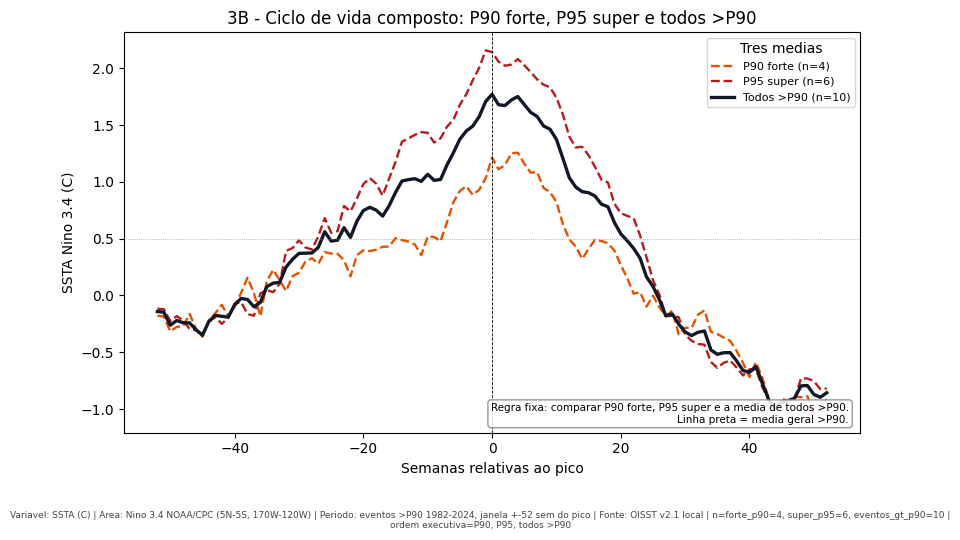

In [2]:
lags=list(range(-52,53))
groups=u.elnino_mean_groups(ev)

def peak_aligned(series,e):
    i=series.index.get_indexer([e.peak_time],method='nearest')[0]
    seg=series.iloc[max(0,i-52):i+53]
    rel=((seg.index-series.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values,index=rel).reindex(lags)

comp={}
for grupo,gg in groups.items():
    frames=[peak_aligned(ssta,e) for _,e in gg.iterrows()]
    comp[grupo]=pd.DataFrame(frames).mean() if frames else pd.Series(index=lags,dtype=float)
comp=pd.DataFrame({g:comp[g] for g in u.ELNINO_MEAN_GROUP_ORDER})
u.save_table(comp.rename_axis('semana_rel_pico'),'phase3B_trajetorias_compostas.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3B_grupos_medias_elnino.csv',index=False)
fig,ax=plt.subplots(figsize=(9.5,5.2))
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    meta=u.elnino_group_style(grupo)
    label=f"{meta['rotulo_curto']} (n={len(groups[grupo])})"
    ax.plot(comp.index,comp[grupo],label=label,color=meta['color'],lw=meta['linewidth'],ls=meta['linestyle'])
ax.axvline(0,color='k',ls='--',lw=.6); ax.axhline(.5,color='grey',ls=':',lw=.5); ax.legend(fontsize=8,title='Tres medias')
ax.set_xlabel('Semanas relativas ao pico'); ax.set_ylabel('SSTA Nino 3.4 (C)'); ax.set_title('3B - Ciclo de vida composto: P90 forte, P95 super e todos >P90')
u.add_note(ax,'Regra fixa: comparar P90 forte, P95 super e a media de todos >P90.\nLinha preta = media geral >P90.',loc='lower right')
counts=ev['classe_p90_p95'].value_counts().to_dict()
u.stamp_caption(fig,variavel='SSTA (C)',area=u.CAIXAS['nino34'],periodo='eventos >P90 1982-2024, janela +-52 sem do pico',
 fonte='OISST v2.1 local',n=f"forte_p90={counts.get('forte_p90',0)}, super_p95={counts.get('super_p95',0)}, eventos_gt_p90={len(ev)}",extra='ordem executiva=P90, P95, todos >P90')
u.save_fig(fig,'phase3B_trajetorias_compostas.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3B_memoria_persistencia.csv


[figura] data\processed\figures\fase3\phase3B_autocorrelacao.png


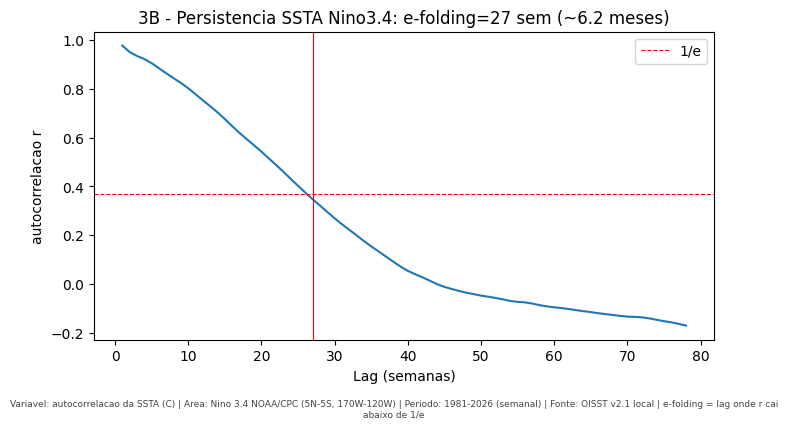

e-folding = 27 semanas


In [3]:
ac=pd.Series({lag:ssta.autocorr(lag) for lag in range(1,79)},name='autocorrelacao')
efold=int(ac[ac<1/np.e].index.min()); mem=ac.to_frame(); mem['abaixo_1_sobre_e']=mem['autocorrelacao']<1/np.e
u.save_table(mem.rename_axis('lag_semanas'),'phase3B_memoria_persistencia.csv')
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(ac.index,ac.values); ax.axhline(1/np.e,color='r',ls='--',lw=.8,label='1/e'); ax.axvline(efold,color='r',lw=.8)
ax.set_xlabel('Lag (semanas)'); ax.set_ylabel('autocorrelacao r'); ax.legend(); ax.set_title(f'3B - Persistencia SSTA Nino3.4: e-folding={efold} sem (~{efold/4.33:.1f} meses)')
u.stamp_caption(fig,variavel='autocorrelacao da SSTA (C)',area=u.CAIXAS['nino34'],periodo='1981-2026 (semanal)',fonte='OISST v2.1 local',extra='e-folding = lag onde r cai abaixo de 1/e')
u.save_fig(fig,'phase3B_autocorrelacao.png'); plt.show(); print('e-folding =',efold,'semanas')

[tabela] data\processed\parquet\statistics\phase3B_mapa_composto_resumo.csv


[figura] data\processed\figures\fase3\phase3B_mapa_composto_super.png


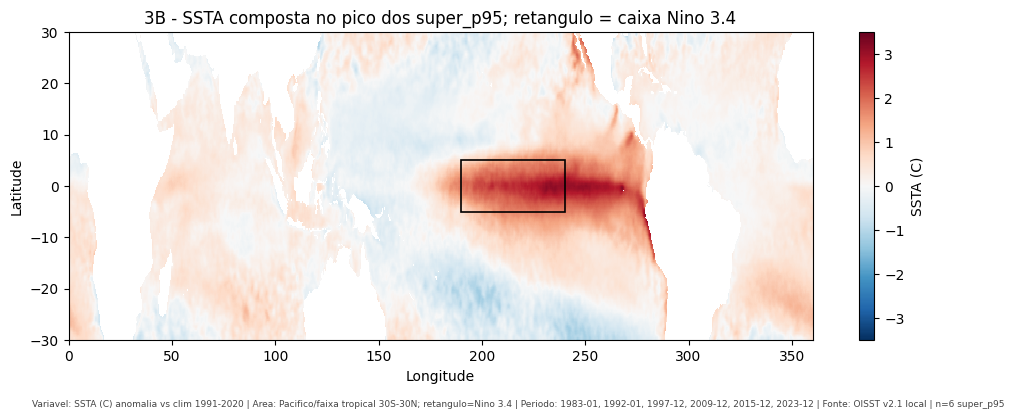

,evento,ssta_max_c,ssta_media_nino34_c
0,1983-01,5.341,2.227
1,1992-01,3.076,1.747
2,1997-12,6.091,2.181
3,2009-12,2.618,1.724
4,2015-12,4.284,2.461
5,2023-12,3.610,2.011


In [4]:
MAPC=u.ROOT/'data/interim/fase3_map_cache'
def mf(y,m):
    f=MAPC/f'sst_month_{y}_{m:02d}.nc'
    if f.exists(): return xr.open_dataarray(f)
    try: ds=xr.open_zarr(u.ROOT/f'data/processed/zarr/cpc_noaa/oisst/sst.day.mean.{y}.zarr',consolidated=False)
    except Exception: ds=xr.open_dataset(u.ROOT/f'data/raw/cpc_noaa/oisst/sst.day.mean.{y}.nc')
    fld=ds['sst'].sel(time=f'{y}-{m:02d}').mean('time').sel(lat=slice(-30,30)).load(); ds.close(); return fld
super_ev=ev.query("classe_p90_p95 == 'super_p95'").copy()
fields=[]
for _,e in super_ev.iterrows():
    y=int(e.peak_time.year); m=int(e.peak_time.month)
    clim=xr.concat([mf(cy,m) for cy in range(1991,2021)],'y').mean('y')
    fields.append((f'{y}-{m:02d}',(mf(y,m)-clim).load()))
cf=xr.concat([f for _,f in fields],'e').mean('e')
fig,ax=plt.subplots(figsize=(12,4)); pc=ax.pcolormesh(cf.lon,cf.lat,cf.values,cmap='RdBu_r',vmin=-3.5,vmax=3.5,shading='auto')
ax.add_patch(plt.Rectangle((190,-5),50,10,fill=False,ec='k',lw=1.2)); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('3B - SSTA composta no pico dos super_p95; retangulo = caixa Nino 3.4')
fig.colorbar(pc,ax=ax,label='SSTA (C)')
u.stamp_caption(fig,variavel='SSTA (C) anomalia vs clim 1991-2020',area='Pacifico/faixa tropical 30S-30N; retangulo=Nino 3.4',
 periodo=', '.join(pk for pk,_ in fields),fonte='OISST v2.1 local',n=f'{len(fields)} super_p95')
res=pd.DataFrame([{'evento':pk,'ssta_max_c':round(float(f.max()),3),'ssta_media_nino34_c':round(float(f.sel(lat=slice(-5,5),lon=slice(190,240)).mean()),3)} for pk,f in fields])
u.save_table(res,'phase3B_mapa_composto_resumo.csv',index=False); u.save_fig(fig,'phase3B_mapa_composto_super.png'); plt.show(); res


**Leitura do 3B.** A Fase 3 usa duas classes executivas (`forte_p90` e `super_p95`) e sempre mostra tambem a media conjunta `eventos_gt_p90`. Eventos abaixo do P90 nao entram nos compostos. A persistencia da SSTA continua em escala semestral (e-folding ~27 semanas), que e o baseline que a Fase 5 tera de superar. O mapa composto `super_p95` confirma que a caixa Nino 3.4 captura o nucleo do aquecimento extremo.
